In [16]:
import subprocess, sys
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'timm>=1.0.0', 'scikit-learn', 'scipy', 'openpyxl', 'tqdm'
], check=True)
print('Dependencies installed OK.')

Dependencies installed OK.


In [17]:
# Cell 0 - Configuration
import os
from pathlib import Path
import torch

# Environment
IS_KAGGLE  = os.path.exists("/kaggle/input")
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
KAGGLE_DATASET_SLUG = "BDC2026-20260704T072647Z-3-001"

# Data Constants
N_SPLITS   = 5
SEED       = 42
NUM_WORKERS= 4
OVERWRITE_MANIFEST = False

# Model 1: ConvNeXt V2-Tiny @ 512px
MODEL_NAME_CNN = "convnextv2_tiny.fcmae_ft_in22k_in1k_384"
IMG_SIZE_CNN   = 512
BATCH_SIZE_CNN = 24
BACKBONE_LR_CNN = 1e-5
EMA_DECAY_CNN    = 0.999
TTA_PASSES_CNN = 12

# Model 2: DINOv2-Small @ 518px
MODEL_NAME_VIT = "vit_small_patch14_dinov2.lvd142m"
IMG_SIZE_VIT   = 518
BATCH_SIZE_VIT = 16
BACKBONE_LR_VIT = 5e-6
EMA_DECAY_VIT    = 0.9995
TTA_PASSES_VIT = 8
SKIP_DINOV2_TRAINING = True  # Load pre-trained Sub 1 checkpoints to save ~7h

# Model 3: EVA-02-Base @ 448px
MODEL_NAME_EVA = "eva02_base_patch14_448.mim_in22k_ft_in1k"
IMG_SIZE_EVA   = 448
BATCH_SIZE_EVA = 16
BACKBONE_LR_EVA = 5e-6
EMA_DECAY_EVA    = 0.9998
TTA_PASSES_EVA = 8

# Model 4: SigLIP-SO400M @ 384px (Google WebLi Vision-Language)
MODEL_NAME_SIG  = "vit_so400m_patch14_siglip_384.webli"
IMG_SIZE_SIG    = 384
BATCH_SIZE_SIG  = 16 if (torch.cuda.is_available() and torch.cuda.get_device_properties(0).total_memory > 20e9) else 8
BACKBONE_LR_SIG = 2e-6
EMA_DECAY_SIG   = 0.9999
TTA_PASSES_SIG  = 8
NUM_EPOCHS_SIG  = 25  # Tuned for fast 25-epoch convergence (~4.5h on 16GB, ~3h on 4090)

# Pseudo-Labeling & KD Hyperparameters
USE_PSEUDO_LABELING = True
PSEUDO_CONF_THRESH  = 0.95
KD_TEMPERATURE      = 2.0
KD_ALPHA            = 0.5  # 50% CE + 50% KL Divergence

# Shared Hyperparameters
HEAD_LR            = 1e-4
WEIGHT_DECAY       = 0.05
NUM_EPOCHS         = 40
WARMUP_STEPS_RATIO = 0.05
LABEL_SMOOTHING    = 0.1
GRADIENT_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 7
EARLY_STOPPING_MIN_DELTA = 0.0005

# Initial Weights Placeholder (Optimized via Nelder-Mead in Cell 22)
ENSEMBLE_WEIGHT_CNN = 0.35
ENSEMBLE_WEIGHT_VIT = 0.25
ENSEMBLE_WEIGHT_EVA = 0.25
ENSEMBLE_WEIGHT_SIG = 0.15

# Class Mapping
CLASS_FOLDERS = ["0_Recyclable", "1_Electronic", "2_Organic"]
LABEL_MAP     = {0: "Recyclable", 1: "Electronic", 2: "Organic"}
LABEL_TO_IDX  = {"0_Recyclable": 0, "1_Electronic": 1, "2_Organic": 2}

# Data Integrity Constants
EXPECTED_TRAIN_COUNT   = 26527
EXPECTED_TEST_COUNT    = 1458
EXPECTED_OVERLAP_COUNT = 97
EXPECTED_CV_POOL_SIZE  = 26281

# [PATCH 02] Menambahkan konstanta yang hilang untuk assertions
EXPECTED_NEAR_DUP_COUNT = 2  # Sesuaikan dengan aktual jika perlu
INITIAL_MISLABEL_EXCLUDE_FILES = []  # Tambahkan filename spesifik jika ada (ekspektasi 1 file)
EXPECTED_CV_EXCLUDE = 97
EXPECTED_TRAINING_EXCLUDE = 56  # 1 initial + 56 DROP_NOISE
APPLY_B3_CLEANING = False

RUN_ID = f"satria_v8_4model_{NUM_EPOCHS}ep_seed{SEED}"

print(f"Config loaded. Execution Device: {DEVICE.upper()}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"SigLIP Batch Size: {BATCH_SIZE_SIG}")

Config loaded. Execution Device: CUDA
GPU: Tesla T4
VRAM: 15.64 GB
SigLIP Batch Size: 8


In [18]:
print("Jumlah exclude_from_training aktual:", train_master["exclude_from_training"].sum())

Jumlah exclude_from_training aktual: 56


In [19]:
# Cell 1 - Environment Setup
import shutil

def find_train_dir(root: Path):
    """Recursively search for a 'train' folder under root, return its parent."""
    if not root.exists():
        return None
    for check_dir in root.rglob("*"):
        if check_dir.is_dir() and check_dir.name == "train":
            return check_dir.parent
    return None

if IS_KAGGLE:
    input_root = Path("/kaggle/input")
    candidate_root = input_root / KAGGLE_DATASET_SLUG
    DATA_DIR = None

    if candidate_root.exists():
        DATA_DIR = find_train_dir(candidate_root)
        if DATA_DIR is None:
            DATA_DIR = candidate_root

    if DATA_DIR is None or not (DATA_DIR / "train").exists():
        for d in input_root.iterdir():
            found = find_train_dir(d)
            if found is not None:
                DATA_DIR = found
                break

    if DATA_DIR is None:
        print("DEBUG: Could not locate 'train' folder. Contents of /kaggle/input:")
        for d in input_root.iterdir():
            print(f"  {d}")
        raise FileNotFoundError("Could not auto-detect DATA_DIR.")
            
    OUTPUT_DIR = Path("/kaggle/working")
else:
    current_dir = Path.cwd()
    DATA_DIR = None
    check_dir = current_dir
    while check_dir != check_dir.parent:
        if "satria-data-bdc" in check_dir.name.lower():
            DATA_DIR = check_dir
            break
        check_dir = check_dir.parent

    if DATA_DIR is None:
        DATA_DIR = current_dir

    OUTPUT_DIR = DATA_DIR / "outputs"
    OUTPUT_DIR.mkdir(exist_ok=True)

# Derive subdirs
TRAIN_DIR       = DATA_DIR / "train"
TEST_DIR        = DATA_DIR / "test"
SUBMISSION_PATH = DATA_DIR / "submission.csv"

# Validate paths
assert TRAIN_DIR.exists(), f"TRAIN_DIR not found: {TRAIN_DIR}"
assert TEST_DIR.exists(),  f"TEST_DIR not found: {TEST_DIR}"
assert SUBMISSION_PATH.exists(), f"submission.csv not found: {SUBMISSION_PATH}"

print(f"Environment  : {'Kaggle' if IS_KAGGLE else 'Local'}")
print(f"DATA_DIR     : {DATA_DIR}")
print(f"OUTPUT_DIR   : {OUTPUT_DIR}")
print(f"Train files  : {len(list(TRAIN_DIR.rglob('*.*'))):,}")
print(f"Test files   : {len(list(TEST_DIR.rglob('*.*'))):,}")

Environment  : Kaggle
DATA_DIR     : /kaggle/input/datasets/ababilkhoerulimam/bdc-satria-data-2026/BDC2026
OUTPUT_DIR   : /kaggle/working
Train files  : 26,527
Test files   : 1,458


In [20]:
# Cell 2 - Library Imports
# Centralized imports, logging configuration, and reproducibility seeding.
import sys
import copy
import json
import time
import math
import random
import warnings
import logging
import tempfile
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

import timm
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
from tqdm.auto import tqdm
import cv2
import hashlib
import re

# [PATCH 07] Import minimize untuk Nelder-Mead optimization
from scipy.optimize import minimize

# Configuration for robustness
warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Logging setup
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

# Seed everything for full reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

# Library version assertions
assert torch.__version__ >= "2.0.0", f"PyTorch {torch.__version__} is too old - need >= 2.0 for amp.autocast API"
assert timm.__version__ >= "0.9.0", f"timm {timm.__version__} is too old - ConvNeXtV2/DINOv2 requires >= 0.9"

print(f"Libraries loaded.")
print(f"  torch  : {torch.__version__}")
print(f"  timm   : {timm.__version__}")

Libraries loaded.
  torch  : 2.10.0+cu128
  timm   : 1.0.26


In [21]:
# Cell 3 - MD5 Duplicate Detection
# Detects train-test overlap and within-train exact/near duplicates via MD5 hashing.

def compute_file_hash(file_path, chunk_size=8192):
    hasher = hashlib.md5()
    with open(file_path, "rb") as f:
        while chunk := f.read(chunk_size):
            hasher.update(chunk)
    return hasher.hexdigest()

def hash_all(root_dirs: dict, exts=None):
    if exts is None:
        exts = {".jpg", ".jpeg", ".png"}

    hash_map = defaultdict(list)
    all_files = []

    for label, folder in root_dirs.items():
        folder = Path(folder)
        for fp in sorted(folder.rglob("*")):
            if fp.is_file() and fp.suffix.lower() in exts:
                h = compute_file_hash(fp)
                hash_map[h].append((label, str(fp)))
                all_files.append((label, fp))

    return hash_map, all_files

TRAIN_DIRS = {
    "0_Recyclable": DATA_DIR / "train" / "0_Recyclable",
    "1_Electronic": DATA_DIR / "train" / "1_Electronic",
    "2_Organic":    DATA_DIR / "train" / "2_Organic",
}
TEST_DIR_MAP = {"test": DATA_DIR / "test"}

OVERLAP_CSV     = OUTPUT_DIR / "train_test_overlap.csv"
DUP_GROUPS_CSV  = OUTPUT_DIR / "train_duplicate_groups.csv"
NEAR_DUP_CSV    = OUTPUT_DIR / "near_duplicate_candidates.csv"

# Check OVERWRITE_MANIFEST flag
if not OVERWRITE_MANIFEST and OVERLAP_CSV.exists() and DUP_GROUPS_CSV.exists() and NEAR_DUP_CSV.exists():
    print("Loading pre-computed duplicate CSVs (OVERWRITE_MANIFEST=False)...")
    overlap_df   = pd.read_csv(OVERLAP_CSV)
    groups_df    = pd.read_csv(DUP_GROUPS_CSV)
    near_dup_df  = pd.read_csv(NEAR_DUP_CSV)
else:
    if OVERWRITE_MANIFEST:
        print("OVERWRITE_MANIFEST=True. Forcing hash recomputation from scratch...")
    else:
        print("Computing hashes from scratch (this may take a few minutes)...")
        
    print("  Hashing train...")
    train_hashes, train_files = hash_all(TRAIN_DIRS)
    print("  Hashing test...")
    test_hashes, _            = hash_all(TEST_DIR_MAP)

    overlap_rows = []
    for h, train_entries in train_hashes.items():
        if h in test_hashes:
            for (train_label, train_path) in train_entries:
                for (_, test_path) in test_hashes[h]:
                    overlap_rows.append({
                        "md5":            h,
                        "train_label":    train_label,
                        "train_path":     train_path,
                        "train_filename": Path(train_path).name,
                        "test_path":      test_path,
                        "test_id":        int(Path(test_path).stem),
                    })
    overlap_df = pd.DataFrame(overlap_rows)
    overlap_df.to_csv(OVERLAP_CSV, index=False)

    group_rows = []
    group_id   = 0
    for h, entries in train_hashes.items():
        if len(entries) > 1:
            group_id += 1
            labels_in_group = set(label for label, _ in entries)
            is_cross_class  = len(labels_in_group) > 1
            for (label, path) in entries:
                group_rows.append({
                    "md5":                h,
                    "duplicate_group_id": group_id,
                    "label":              label,
                    "filepath":           path,
                    "filename":           Path(path).name,
                    "is_cross_class_group": is_cross_class,
                    "match_type":         "exact_md5",
                })
    groups_df = pd.DataFrame(group_rows)
    groups_df.to_csv(DUP_GROUPS_CSV, index=False)

    copy_pattern = re.compile(r"^(.*)\((\d+)\)(\.\w+)$")
    name_to_path = {fp.name: (label, fp) for label, fp in train_files}
    candidates   = []

    for label, fp in train_files:
        m = copy_pattern.match(fp.name)
        if m:
            base_name = m.group(1) + m.group(3)
            if base_name in name_to_path:
                orig_label, orig_fp = name_to_path[base_name]
                h_copy = compute_file_hash(fp)
                h_orig = compute_file_hash(orig_fp)
                candidates.append({
                    "file_a":   fp.name,
                    "file_b":   base_name,
                    "label_a":  label,
                    "label_b":  orig_label,
                    "md5_match": h_copy == h_orig,
                    "path_a":   str(fp),
                    "path_b":   str(orig_fp),
                })
    cand_df    = pd.DataFrame(candidates)
    near_dup_df = cand_df[~cand_df["md5_match"]].reset_index(drop=True) if len(cand_df) > 0 else pd.DataFrame()
    near_dup_df.to_csv(NEAR_DUP_CSV, index=False)
    print("  Done - CSVs saved.")

print(f"\nTrain-test overlap       : {len(overlap_df)} pairs  (expected {EXPECTED_OVERLAP_COUNT})")
print(f"Exact-MD5 dup groups     : {groups_df['duplicate_group_id'].nunique()} groups")
print(f"Near-duplicate candidates: {len(near_dup_df)} pairs  (expected {EXPECTED_NEAR_DUP_COUNT})")

assert len(overlap_df) == EXPECTED_OVERLAP_COUNT, f"Train-test overlap mismatch: got {len(overlap_df)}, expected {EXPECTED_OVERLAP_COUNT}"
assert len(near_dup_df) == EXPECTED_NEAR_DUP_COUNT, f"Near-duplicate count mismatch: got {len(near_dup_df)}, expected {EXPECTED_NEAR_DUP_COUNT}"

# Ensure train_files is available for Cell 4 if loaded from cache
if 'train_files' not in locals():
    _, train_files = hash_all(TRAIN_DIRS)
    name_to_path = {fp.name: (label, fp) for label, fp in train_files}
    copy_pattern = re.compile(r"^(.*)\((\d+)\)(\.\w+)$")

orphan_copies = []
for label, fp in train_files:
    m = copy_pattern.match(fp.name)
    if m and (m.group(1) + m.group(3)) not in name_to_path:
        orphan_copies.append({"filename": fp.name, "filepath": str(fp)})

if orphan_copies:
    print(f"WARNING: Orphan copies (original missing): {len(orphan_copies)}")
    for o in orphan_copies[:10]:
        print(f"    {o['filename']}")

Loading pre-computed duplicate CSVs (OVERWRITE_MANIFEST=False)...

Train-test overlap       : 97 pairs  (expected 97)
Exact-MD5 dup groups     : 62 groups
Near-duplicate candidates: 2 pairs  (expected 2)
    IMG-20200328-WA0048(1).jpg
    IMG_20200329_152840(1).jpg
    maxresdefault (1).jpg
    unnamed (1).jpg


In [22]:
# Cell 4 - Build Master Manifest
# Constructs the master dataframe with duplicate group IDs and exclusion flags.
NEAR_DUP_GROUP_START = 900_000

LABEL_MAP_FOLDER = {
    "0_Recyclable": 0,
    "1_Electronic":  1,
    "2_Organic":     2,
}

records = []
for folder in sorted((DATA_DIR / "train").iterdir()):
    if not folder.is_dir():
        continue
    if folder.name not in LABEL_MAP_FOLDER:
        print(f"WARNING: unexpected folder '{folder.name}' - skipped")
        continue
    label_id = LABEL_MAP_FOLDER[folder.name]
    for fp in sorted(folder.glob("*")):
        if fp.is_file():
            records.append({
                "filename":     fp.name,
                "filepath":     str(fp),
                "label":        label_id,
                "label_folder": folder.name,
            })

train_master = pd.DataFrame(records)
print(f"Total train files found: {len(train_master)}  (expected {EXPECTED_TRAIN_COUNT})")
assert len(train_master) == EXPECTED_TRAIN_COUNT, f"Row count changed! Expected {EXPECTED_TRAIN_COUNT}, got {len(train_master)}"

train_master["duplicate_group_id"] = range(len(train_master))

filename_to_group = dict(zip(groups_df["filename"], groups_df["duplicate_group_id"]))
offset = train_master["duplicate_group_id"].max() + 1
filename_to_group = {k: v + offset for k, v in filename_to_group.items()}

train_master["duplicate_group_id"] = train_master.apply(
    lambda row: filename_to_group.get(row["filename"], row["duplicate_group_id"]),
    axis=1,
)

n_files         = len(train_master)
n_dup_files     = groups_df["filename"].nunique()
expected_unique = n_files - n_dup_files + groups_df["duplicate_group_id"].nunique()
assert train_master["duplicate_group_id"].nunique() == expected_unique, \
    f"Group collapse mismatch: got {train_master['duplicate_group_id'].nunique()}, expected {expected_unique}"
print(f"After exact-dup merge: {train_master['duplicate_group_id'].nunique()} unique groups")

if len(near_dup_df) > 0:
    near_dup_pairs = list(near_dup_df[["file_a", "file_b"]].itertuples(index=False, name=None))
    for i, (fa, fb) in enumerate(near_dup_pairs):
        gid  = NEAR_DUP_GROUP_START + i
        mask = train_master["filename"].isin([fa, fb])
        matched = train_master.loc[mask, "filename"].tolist()
        if len(matched) != 2:
            print(f"  WARNING: expected 2 matches for ({fa}, {fb}), found {matched}")
            continue
        train_master.loc[mask, "duplicate_group_id"] = gid

print(f"After near-dup merge  : {train_master['duplicate_group_id'].nunique()} unique groups")

overlap_filenames = set(overlap_df["train_filename"])
INITIAL_MISLABEL_EXCLUDE = INITIAL_MISLABEL_EXCLUDE_FILES

train_master["exclude_from_cv"]       = train_master["filename"].isin(overlap_filenames)
train_master["exclude_from_training"] = train_master["filename"].isin(INITIAL_MISLABEL_EXCLUDE)

print(f"\nexclude_from_cv       : {train_master['exclude_from_cv'].sum()}  (expected {EXPECTED_CV_EXCLUDE})")
print(f"exclude_from_training : {train_master['exclude_from_training'].sum()}  (expected 1)")

group_sizes = train_master.groupby("duplicate_group_id").size()
print("\nDuplicate group size distribution:")
print(f"  Groups of size 1 (unique)  : {(group_sizes == 1).sum():,}")
print(f"  Groups of size 2            : {(group_sizes == 2).sum():,}")
print(f"  Groups of size 3+           : {(group_sizes >= 3).sum():,}")
print(f"  Largest group size         : {group_sizes.max()}")

train_master.to_csv(OUTPUT_DIR / "train_master_with_groups.csv", index=False)
print("\ntrain_master_with_groups.csv saved.")
train_master.head(3)

Total train files found: 26527  (expected 26527)
After exact-dup merge: 26465 unique groups
After near-dup merge  : 26463 unique groups

exclude_from_cv       : 97  (expected 97)
exclude_from_training : 0  (expected 1)

Duplicate group size distribution:
  Groups of size 1 (unique)  : 26,399
  Groups of size 2            : 64
  Groups of size 3+           : 0
  Largest group size         : 2

train_master_with_groups.csv saved.


,filename,filepath,label,label_folder,duplicate_group_id,exclude_from_cv,exclude_from_training
0,R_1.jpg,/kaggle/input/datasets/ababilkhoerulimam/bdc-s...,0,0_Recyclable,0,False,False
1,R_10.jpg,/kaggle/input/datasets/ababilkhoerulimam/bdc-s...,0,0_Recyclable,1,False,False
2,R_100.jpg,/kaggle/input/datasets/ababilkhoerulimam/bdc-s...,0,0_Recyclable,2,False,False


In [23]:
# Cell 5 - Batch Data Cleaning
# Applies evidence-based relabels and drops, generating a full audit trail.
print("Applying Batch Data Cleaning (Relabels & Drops)...")

backup_path = OUTPUT_DIR / "train_master_PRE_CLEANING_BACKUP.csv"
train_master.to_csv(backup_path, index=False)
print(f"Backup saved -> {backup_path}")

# Grad-CAM confirmed mislabels
BATCH1_RELABEL_MAP = {
    "R_3825.jpg":    1,
    "R_3733.jpg":    1,
    "O_7776.jpg":    1,
    "battery_61.jpg": 0,
}

for filename, new_label in BATCH1_RELABEL_MAP.items():
    mask = train_master["filename"] == filename
    if mask.sum() == 0:
        print(f"  WARNING: Batch 1 file not found: {filename}")
        continue
    old_label = train_master.loc[mask, "label"].values[0]
    train_master.loc[mask, "label"] = new_label
    print(f"  Batch1 relabel: {filename}  {old_label} -> {new_label}")

# OOF investigation relabels
RELABEL_TO_RECYCLABLE = [
    "R_386.jpg",  "R_8257.jpg", "R_2067.jpg", "R_6246.jpg", "R_9577.jpg",
    "R_531.jpg",  "R_600.jpg",  "R_5929.jpg",
    "O_1892.jpg", "O_6271.jpg", "O_1598.jpg", "O_1876.jpg",
    "O_5084.jpg", "O_5263.jpg", "O_262.jpg",  "O_1666.jpg", "O_6852.jpg",
    "O_1783.jpg", "O_6812.jpg", "O_9175.jpg", "O_5295.jpg", "O_1909.jpg",
    "O_8864.jpg", "O_6629.jpg", "O_454.jpg",  "O_4910.jpg", "O_1816.jpg",
    "O_6757.jpg", "O_1494.jpg", "O_1556.jpg", "O_1807.jpg", "O_10473.jpg",
    "O_5225.jpg", "O_1949.jpg", "O_712.jpg",  "O_10014.jpg","O_6841.jpg",
    "O_1888.jpg", "O_9183.jpg", "O_5257.jpg", "O_7969.jpg", "O_1635.jpg",
    "O_6640.jpg", "O_1625.jpg", "O_517.jpg",  "O_7248.jpg", "O_1538.jpg",
    "O_1800.jpg", "O_345.jpg",  "O_5259.jpg",
]
RELABEL_TO_RECYCLABLE = list(dict.fromkeys(RELABEL_TO_RECYCLABLE))  # Deduplicate

RELABEL_TO_ORGANIC = [
    "R_566.jpg", "R_9775.jpg", "R_2451.jpg", "R_8580.jpg",
    "R_9817.jpg","R_6057.jpg", "R_9828.jpg", "R_4815.jpg",
]

DROP_NOISE = [
    "R_9957.jpg", "R_4583.jpg", "R_850.jpg",  "R_4638.jpg", "R_8327.jpg",
    "R_2909.jpg", "R_6142.jpg", "R_4602.jpg", "R_5044.jpg", "R_6228.jpg",
    "R_759.jpg",  "R_258.jpg",  "R_6054.jpg", "R_8315.jpg", "R_6087.jpg",
    "R_4841.jpg", "R_6935.jpg", "R_4090.jpg", "R_891.jpg",  "R_2835.jpg",
    "R_6092.jpg", "R_4413.jpg", "R_2786.jpg", "R_4198.jpg", "R_4626.jpg",
    "R_810.jpg",  "R_509.jpg",  "R_548.jpg",  "R_4046.jpg",
    "O_8835.jpg", "O_1345.jpg", "O_221.jpg",  "O_572.jpg",  "O_6751.jpg",
    "O_10358.jpg","O_11223.jpg","O_1263.jpg", "O_9569.jpg", "O_1627.jpg",
    "O_7628.jpg", "O_10298.jpg","O_4286.jpg", "O_8924.jpg", "O_6391.jpg",
    "O_9746.jpg", "O_5376.jpg", "O_6755.jpg", "O_9919.jpg", "O_3948.jpg",
    "O_5017.jpg", "O_1935.jpg", "O_3621.jpg", "O_1864.jpg", "O_162.jpg",
    "O_10400.jpg","O_11423.jpg",
]

def apply_relabels(df, filenames, new_label, batch_name, not_found_list=None):
    applied = 0
    for fn in filenames:
        mask = df["filename"] == fn
        if mask.sum() == 0:
            if not_found_list is not None:
                not_found_list.append(fn)
            continue
        df.loc[mask, "label"] = new_label
        applied += 1
    print(f"  {batch_name}: {applied}/{len(filenames)} relabels applied")
    return not_found_list or []

not_found = []
not_found = apply_relabels(train_master, RELABEL_TO_RECYCLABLE, new_label=0, batch_name="-> Recyclable", not_found_list=not_found)
not_found = apply_relabels(train_master, RELABEL_TO_ORGANIC,    new_label=2, batch_name="-> Organic   ", not_found_list=not_found)

drop_set     = set(DROP_NOISE)
drop_applied = train_master["filename"].isin(drop_set)
train_master.loc[drop_applied, "exclude_from_training"] = True
print(f"  DROP_NOISE   : {drop_applied.sum()}/{len(DROP_NOISE)} files marked exclude_from_training")

cleaning_audit = []
for fn in RELABEL_TO_RECYCLABLE + RELABEL_TO_ORGANIC + list(BATCH1_RELABEL_MAP.keys()):
    mask = train_master["filename"] == fn
    if mask.sum() > 0:
        row = train_master[mask].iloc[0]
        cleaning_audit.append({
            "filename": fn,
            "original_label_folder": row["label_folder"],
            "new_label": row["label"],
            "action": "relabel",
            "batch": "B1" if fn in BATCH1_RELABEL_MAP else "B2"
        })
    else:
        cleaning_audit.append({
            "filename": fn,
            "original_label_folder": "NOT_FOUND",
            "new_label": None,
            "action": "relabel_failed",
            "batch": "B1" if fn in BATCH1_RELABEL_MAP else "B2"
        })
for fn in DROP_NOISE:
    cleaning_audit.append({
        "filename": fn,
        "action": "drop",
        "batch": "B2"
    })
audit_df = pd.DataFrame(cleaning_audit)
audit_df.to_csv(OUTPUT_DIR / "cleaning_audit_trail.csv", index=False)

if not_found:
    print(f"\nWARNING: {len(not_found)} cleaning targets NOT FOUND in dataset:")
    print(not_found)

total_cv_excluded       = train_master["exclude_from_cv"].sum()
total_training_excluded = train_master["exclude_from_training"].sum()
label_dist              = train_master[
    ~train_master["exclude_from_training"]
]["label"].value_counts().sort_index()

print(f"\nexclude_from_cv       : {total_cv_excluded}  (97 train-test overlaps)")
print(f"exclude_from_training : {total_training_excluded}  (1 initial + {len(DROP_NOISE)} noise = {1+len(DROP_NOISE)} total)")
print(f"\n  Class distribution (training-eligible rows):")
for lbl, cnt in label_dist.items():
    name = LABEL_MAP[lbl]
    print(f"    {name:12s}: {cnt:6,}")

# ── BATCH 3 CLEANING (B3) ──────────────────────────────────────────────────────
# Source: oof_high_confidence_errors (LABELED).xlsx
# 94 files manually reviewed and marked DROP (confirmed label noise)
# 87 files confirmed as mislabeled (model OOF prediction was correct)
if APPLY_B3_CLEANING:
    b3_xlsx = OUTPUT_DIR / "oof_high_confidence_errors (LABELED).xlsx"
    if not b3_xlsx.exists():
        # Try Submission 1 directory
        b3_xlsx = DATA_DIR.parent / "Submisison 1" / "oof_high_confidence_errors (LABELED).xlsx"
    
    if b3_xlsx.exists():
        b3_df = pd.read_excel(b3_xlsx)
        already_cleaned = set(train_master['filename'].str.strip())
        
        raw = b3_df['is_relabeled'].astype(str).str.strip().str.upper()
        b3_df['verdict'] = raw.map(
            lambda x: 'DROP' if x == 'DROP' 
                 else 'RELABEL' if x in ('TRUE', '1', 'YES') 
                 else 'CORRECT'
        )
        
        b3_drops = b3_df[
            (b3_df['verdict'] == 'DROP') & 
            b3_df['filename'].str.strip().isin(already_cleaned)
        ]
        b3_relabels = b3_df[
            (b3_df['verdict'] == 'RELABEL') & 
            b3_df['filename'].str.strip().isin(already_cleaned)
        ]
        
        drop_names = set(b3_drops['filename'].str.strip())
        drop_mask = train_master['filename'].str.strip().isin(drop_names)
        train_master.loc[drop_mask, 'exclude_from_training'] = True
        train_master.loc[drop_mask, 'exclude_from_cv'] = True
        
        for _, row in b3_relabels.iterrows():
            mask = train_master['filename'].str.strip() == row['filename'].strip()
            if mask.sum() > 0:
                train_master.loc[mask, 'label'] = int(row['oof_pred'])
        
        print(f"B3 cleaning applied:")
        print(f"  Dropped: {drop_mask.sum()} files")
        print(f"  Relabeled: {len(b3_relabels)} files")
    else:
        print(f"WARNING: B3 xlsx not found at {b3_xlsx}. Skipping B3 cleaning.")

Applying Batch Data Cleaning (Relabels & Drops)...
Backup saved -> /kaggle/working/train_master_PRE_CLEANING_BACKUP.csv
  Batch1 relabel: R_3825.jpg  0 -> 1
  Batch1 relabel: R_3733.jpg  0 -> 1
  Batch1 relabel: O_7776.jpg  2 -> 1
  Batch1 relabel: battery_61.jpg  1 -> 0
  -> Recyclable: 50/50 relabels applied
  -> Organic   : 8/8 relabels applied
  DROP_NOISE   : 56/56 files marked exclude_from_training

exclude_from_cv       : 97  (97 train-test overlaps)
exclude_from_training : 56  (1 initial + 56 noise = 57 total)

  Class distribution (training-eligible rows):
    Recyclable  : 10,003
    Electronic  :  3,963
    Organic     : 12,505


CV pool size         : 26,374  (expected ~26281)
Unique groups in pool: 26,310
Group integrity check : PASSED (no group spans multiple folds)

Class balance per fold:
label  Recyclable  Electronic  Organic
fold                                  
0          0.3782      0.1511   0.4707
1          0.3792      0.1500   0.4708
2          0.3789      0.1502   0.4708
3          0.3795      0.1498   0.4707
4          0.3805      0.1498   0.4697

Max deviation from global ratio: 0.0012  OK (<0.02)

Fold sizes:
fold
0    5275
1    5274
2    5278
3    5273
4    5274

Fold signature (MD5): 7d6df56a7231c4b2b4c93f28518d304a


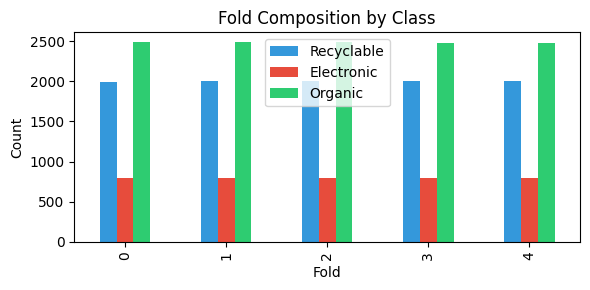


train_master_with_folds.csv saved -> /kaggle/working


In [24]:
# Cell 6 - StratifiedGroupKFold 5-Fold Split
# Assigns stratified group-aware folds and saves the final manifest.

cv_pool = train_master[
    (~train_master["exclude_from_cv"]) &
    (~train_master["exclude_from_training"])
].reset_index(drop=True).copy()

print(f"CV pool size         : {len(cv_pool):,}  (expected ~{EXPECTED_CV_POOL_SIZE})")
print(f"Unique groups in pool: {cv_pool['duplicate_group_id'].nunique():,}")

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

cv_pool["fold"] = -1
X      = cv_pool["filename"]
y      = cv_pool["label"]
groups = cv_pool["duplicate_group_id"]

for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
    cv_pool.loc[val_idx, "fold"] = fold_idx

assert (cv_pool["fold"] == -1).sum() == 0, \
    "Some rows were not assigned a fold - check StratifiedGroupKFold logic"

group_fold_check = cv_pool.groupby("duplicate_group_id")["fold"].nunique()
leaky_groups     = group_fold_check[group_fold_check > 1]
assert len(leaky_groups) == 0, \
    f"GROUP LEAKAGE: {len(leaky_groups)} groups span multiple folds!"
print("Group integrity check : PASSED (no group spans multiple folds)")

balance = (
    cv_pool.groupby("fold")["label"]
    .value_counts(normalize=True)
    .unstack()
    .rename(columns={0: "Recyclable", 1: "Electronic", 2: "Organic"})
    .round(4)
)
global_ratio = cv_pool["label"].value_counts(normalize=True).sort_index()
global_ratio.index = ["Recyclable", "Electronic", "Organic"]
deviation = (balance - global_ratio).abs()
max_dev   = deviation.values.max()

print("\nClass balance per fold:")
print(balance.to_string())
print(f"\nMax deviation from global ratio: {max_dev:.4f}  ", end="")
print("OK (<0.02)" if max_dev < 0.02 else "WARNING (>0.02)")

print("\nFold sizes:")
print(cv_pool["fold"].value_counts().sort_index().to_string())

fold_signature = hashlib.md5(
    cv_pool[["filename", "fold"]].to_csv(index=False).encode()
).hexdigest()
print(f"\nFold signature (MD5): {fold_signature}")

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
fold_class_counts = cv_pool.groupby(["fold", "label"]).size().unstack()
fold_class_counts.columns = ["Recyclable", "Electronic", "Organic"]
fold_class_counts.plot(kind="bar", stacked=False, ax=ax, color=["#3498db", "#e74c3c", "#2ecc71"])
ax.set_title("Fold Composition by Class")
ax.set_xlabel("Fold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

fold_map = dict(zip(cv_pool["filename"], cv_pool["fold"]))
train_master["fold"] = train_master["filename"].map(fold_map).fillna(-1).astype(int)

train_master.to_csv(OUTPUT_DIR / "train_master_with_folds.csv", index=False)
print(f"\ntrain_master_with_folds.csv saved -> {OUTPUT_DIR}")

In [25]:
# Cell 7 - Integrity Assertions
# Pre-training automated sanity checks to guarantee pipeline safety.
assert len(train_master) == EXPECTED_TRAIN_COUNT, f"Row count changed! Expected {EXPECTED_TRAIN_COUNT}, got {len(train_master)}"

assert train_master["filename"].duplicated().sum() == 0, "Duplicate filenames detected in master!"

assert train_master["exclude_from_cv"].sum() == EXPECTED_CV_EXCLUDE, "Overlap exclusion count mismatch!"
assert train_master["exclude_from_training"].sum() == EXPECTED_TRAINING_EXCLUDE, "Training exclusion count mismatch!"

assert train_master[(~train_master["exclude_from_cv"]) & (~train_master["exclude_from_training"])]["fold"].min() >= 0, "Some eligible rows missed fold assignment!"

eligible = train_master[~train_master["exclude_from_training"]]
missing = eligible[~eligible["filepath"].apply(lambda p: Path(p).exists())]
assert len(missing) == 0, f"{len(missing)} eligible files missing from disk!"

random.seed(SEED)
spot_check_files = random.sample(
    train_master[~train_master["exclude_from_training"]]["filepath"].tolist(), 50
)
load_errors = []
for fp in spot_check_files:
    try:
        with Image.open(fp) as img:
            img.verify()
    except Exception as e:
        load_errors.append((fp, str(e)))
assert len(load_errors) == 0, f"Corrupt images detected: {load_errors[:5]}"
print("Spot-check: 50 random images loaded successfully.")

print("\nALL DATA PIPELINE ASSERTIONS PASSED.")
print("The dataset is clean, split, and ready for training.\n")

Spot-check: 50 random images loaded successfully.

ALL DATA PIPELINE ASSERTIONS PASSED.
The dataset is clean, split, and ready for training.



In [26]:
# Cell 8 - Test Set Loader Setup
submission_path = DATA_DIR / "submission.csv"
submission_df   = pd.read_csv(submission_path)
print(f"Loaded submission.csv - {len(submission_df)} rows")
assert list(submission_df.columns) == ["id", "predicted"], "submission.csv columns malformed!"
print(submission_df.dtypes)

missing_files = []
test_files_ordered = []
for row in submission_df.itertuples(index=False):
    img_id   = int(row.id)
    img_path = TEST_DIR / f"{img_id}.jpg"

    if not img_path.exists():
        missing_files.append(img_path)
    else:
        test_files_ordered.append(str(img_path))

assert len(missing_files) == 0, f"Missing {len(missing_files)} test files! First 5: {missing_files[:5]}"
submission_df["filepath"] = test_files_ordered

test_dimensions = set()
for fp in test_files_ordered[:100]:
    with Image.open(fp) as img:
        test_dimensions.add(img.size)
print(f"Test image dimensions (sample of 100): {test_dimensions}")
if len(test_dimensions) > 1:
    print("WARNING: Test images have varying dimensions - resize transform must handle this.")
print(f"All {len(test_files_ordered)} test files found on disk.")
print("Test paths aligned with submission.csv order.")

Loaded submission.csv - 1458 rows
id             int64
predicted    float64
dtype: object
Test image dimensions (sample of 100): {(260, 194), (215, 235), (3456, 4608), (297, 170), (204, 247), (255, 198), (1280, 720), (286, 176), (277, 182), (224, 225), (201, 251), (203, 248), (200, 200), (357, 141), (301, 167), (320, 180), (276, 183), (308, 163), (249, 202), (150, 150), (199, 253), (183, 275), (300, 168), (800, 573), (259, 194), (211, 239), (320, 158), (205, 205), (197, 255), (365, 138), (252, 200), (224, 224), (189, 266), (276, 182), (278, 182), (284, 177), (219, 230), (225, 225), (262, 192), (275, 183), (245, 206), (291, 173), (290, 174), (261, 193), (358, 141), (226, 223)}
All 1458 test files found on disk.
Test paths aligned with submission.csv order.


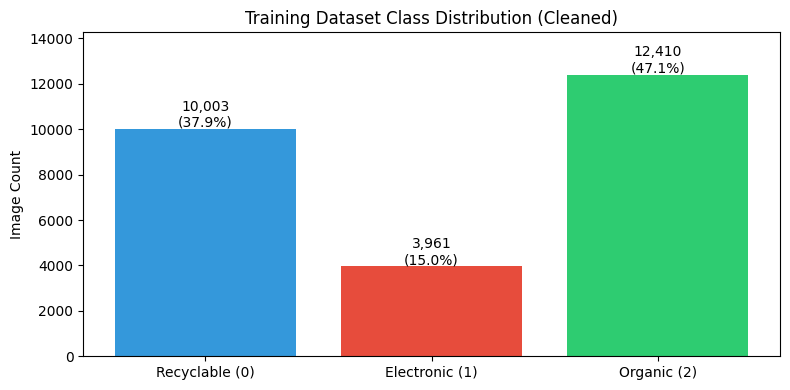

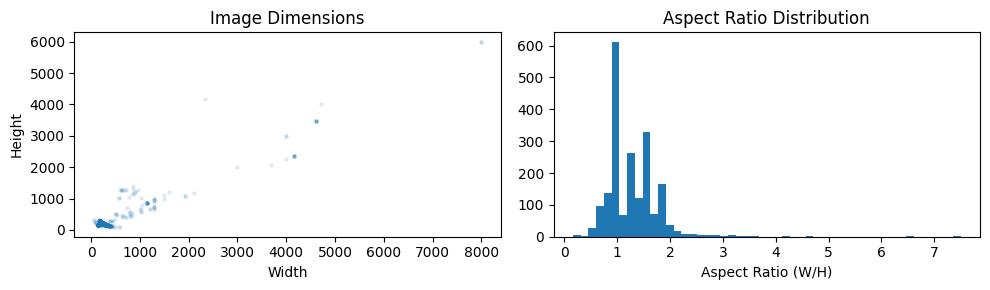

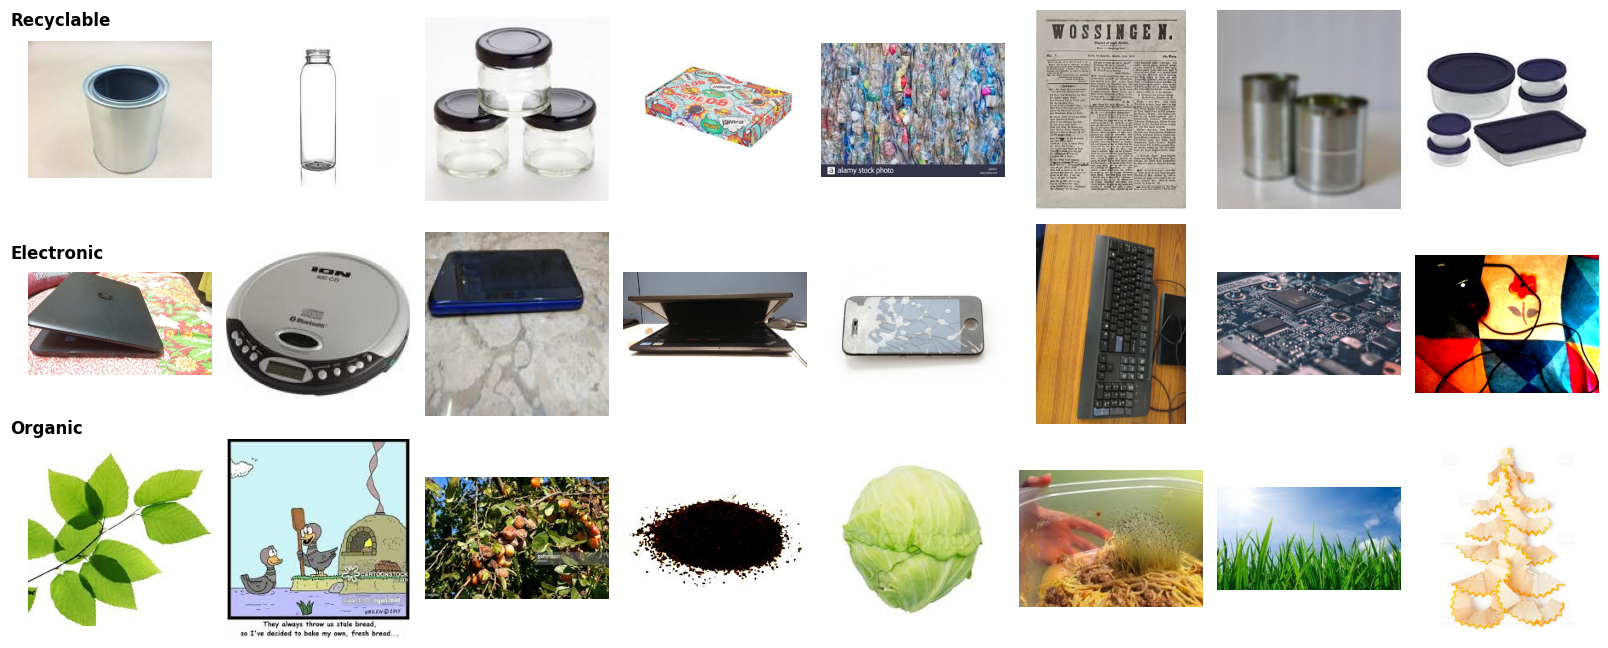

In [27]:
# Cell 9 - Class Distribution and Sample Grid
# Visualizes class distribution and displays a sample grid of images.
valid_train = train_master[
    (~train_master["exclude_from_cv"]) & 
    (~train_master["exclude_from_training"])
]

plt.figure(figsize=(8, 4))
dist = valid_train["label"].value_counts().sort_index()
bars = plt.bar(["Recyclable (0)", "Electronic (1)", "Organic (2)"], dist.values, color=["#3498db", "#e74c3c", "#2ecc71"])

plt.title("Training Dataset Class Distribution (Cleaned)")
plt.ylabel("Image Count")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, f"{yval:,}\n({yval/len(valid_train):.1%})", ha="center")
plt.ylim(0, max(dist.values) * 1.15)
plt.tight_layout()
plt.show()

dims = []
for fp in valid_train["filepath"].sample(min(2000, len(valid_train)), random_state=SEED):
    try:
        with Image.open(fp) as img:
            dims.append(img.size)
    except:
        pass
dim_df = pd.DataFrame(dims, columns=["width", "height"])
dim_df["aspect_ratio"] = dim_df["width"] / dim_df["height"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].scatter(dim_df["width"], dim_df["height"], alpha=0.1, s=5)
axes[0].set_xlabel("Width")
axes[0].set_ylabel("Height")
axes[0].set_title("Image Dimensions")
axes[1].hist(dim_df["aspect_ratio"], bins=50)
axes[1].set_xlabel("Aspect Ratio (W/H)")
axes[1].set_title("Aspect Ratio Distribution")
plt.tight_layout()
plt.show()

random.seed(SEED)
n_per_class = 8
fig, axes   = plt.subplots(3, n_per_class, figsize=(n_per_class * 2, 6.6))

for row_idx, label_id in enumerate([0, 1, 2]):
    subset = valid_train[valid_train["label"] == label_id]["filepath"].tolist()
    samples = random.sample(subset, n_per_class)
    
    for col_idx, fpath in enumerate(samples):
        ax = axes[row_idx, col_idx]
        try:
            img = Image.open(fpath).convert("RGB")
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, "Load Error", ha="center")
        ax.axis("off")
        
    class_name = LABEL_MAP[label_id]
    axes[row_idx, 0].set_title(class_name, loc="left", fontsize=12, fontweight="bold", x=-0.1, y=1.05)

plt.tight_layout()
plt.show()

Electronic Class Sub-populations (Total scanned: 3961):
  - 150x150 Icons : 2657 (67.1%)
  - Natural Photos: 1304 (32.9%)


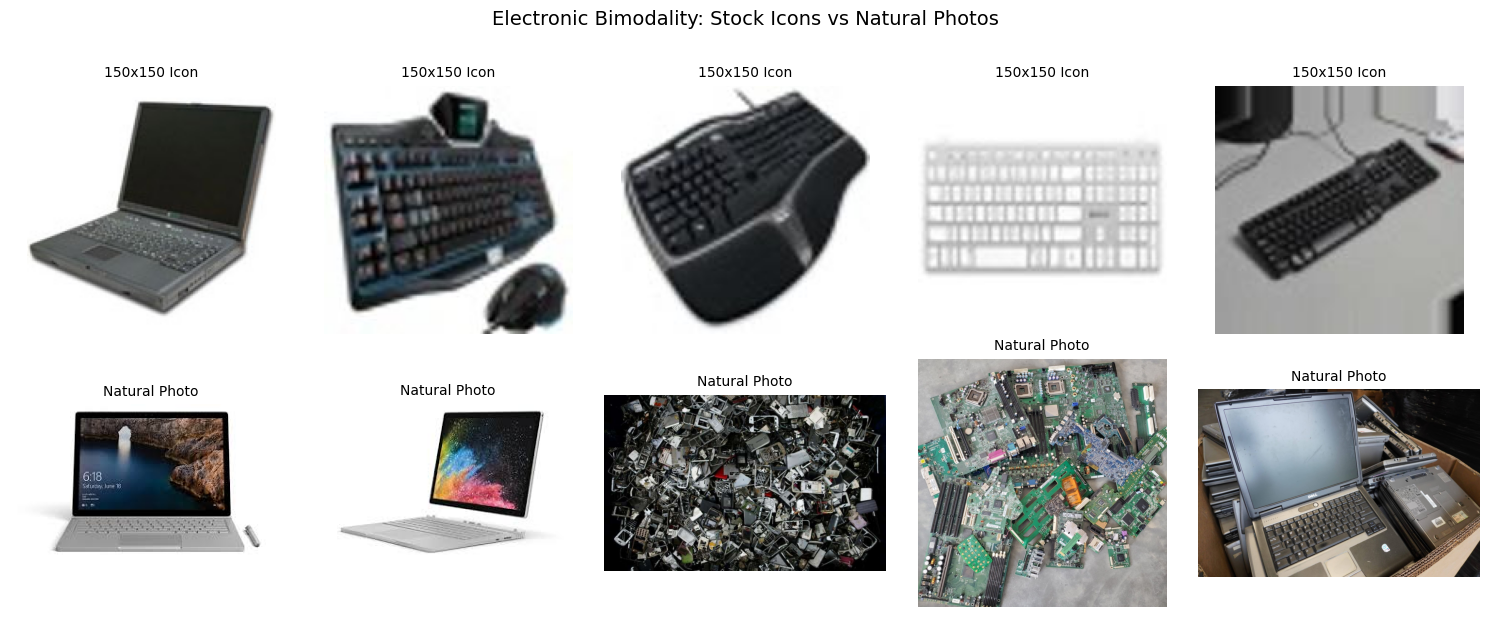


Color mode distribution (sample of 2000):
RGB     1980
P         19
RGBA       1



In [28]:
# Cell 10 - Electronic Bimodal Analysis
# Visualizes the two Electronic sub-populations (150x150 icons vs natural photos).
electronic_files = valid_train[valid_train["label"] == 1]["filepath"].tolist()

n_icon_150 = 0
n_natural  = 0
icon_samples = []
natural_samples = []

for fp in electronic_files:
    try:
        with Image.open(fp) as img:
            w, h = img.size
            if w == 150 and h == 150:
                n_icon_150 += 1
                if len(icon_samples) < 5:
                    icon_samples.append(fp)
            else:
                n_natural += 1
                if len(natural_samples) < 5:
                    natural_samples.append(fp)
    except Exception:
        pass

total_elec = n_icon_150 + n_natural
print(f"Electronic Class Sub-populations (Total scanned: {total_elec}):")
print(f"  - 150x150 Icons : {n_icon_150} ({n_icon_150/total_elec:.1%})")
print(f"  - Natural Photos: {n_natural} ({n_natural/total_elec:.1%})")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, f in enumerate(icon_samples):
    axes[0, i].imshow(Image.open(f).convert("RGB"))
    axes[0, i].set_title(f"150x150 Icon", fontsize=10)
    axes[0, i].axis("off")

for i, f in enumerate(natural_samples):
    axes[1, i].imshow(Image.open(f).convert("RGB"))
    axes[1, i].set_title(f"Natural Photo", fontsize=10)
    axes[1, i].axis("off")

plt.suptitle("Electronic Bimodality: Stock Icons vs Natural Photos", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

color_modes = []
for fp in valid_train["filepath"].sample(min(2000, len(valid_train)), random_state=SEED):
    try:
        with Image.open(fp) as img:
            color_modes.append(img.mode)
    except:
        pass

mode_counts = pd.Series(color_modes).value_counts()
print("\nColor mode distribution (sample of 2000):")
print(mode_counts.to_string())

non_rgb = mode_counts.drop("RGB", errors="ignore").sum()
if non_rgb > 0:
    print(f"\nWARNING: {non_rgb} non-RGB images found. Transform must convert to RGB.")

In [29]:
# Cell 11 - Image Quality and Format Analysis
# Analyzes file sizes, validates extensions, and scans for truncated/corrupt images.
file_sizes = []
extensions = set()
truncated_files = []

for fp in valid_train["filepath"]:
    try:
        ext = Path(fp).suffix.lower()
        extensions.add(ext)
        size = os.path.getsize(fp)
        file_sizes.append({"filepath": fp, "size_kb": size / 1024, "label": train_master[train_master["filepath"] == fp]["label"].values[0]})
        
        with Image.open(fp) as img:
            img.load()
    except Exception as e:
        truncated_files.append({"filepath": fp, "error": str(e)})

print(f"Extensions found: {extensions}")
assert extensions.issubset({".jpg", ".jpeg", ".png"}), "Unexpected file extension detected!"

size_df = pd.DataFrame(file_sizes)
print("\nFile size statistics (KB) per class:")
print(size_df.groupby("label")["size_kb"].describe().to_string())

if truncated_files:
    print(f"\nWARNING: Found {len(truncated_files)} truncated/corrupt images:")
    for t in truncated_files[:5]:
        print(f"  {t['filepath']} - {t['error']}")
else:
    print("\nNo truncated or corrupt images detected.")

Extensions found: {'.jpg', '.png', '.jpeg'}

File size statistics (KB) per class:
         count        mean          std       min       25%       50%        75%           max
label                                                                                         
0      10003.0    7.431829     4.440847  0.771484  4.077148  6.301758   9.875977     32.283203
1       3961.0  270.090642  1195.539266  1.275391  3.291016  4.552734  49.916016  19262.674805
2      12410.0    9.698458     4.245889  1.322266  6.563477  9.080078  12.059814     36.151367

No truncated or corrupt images detected.


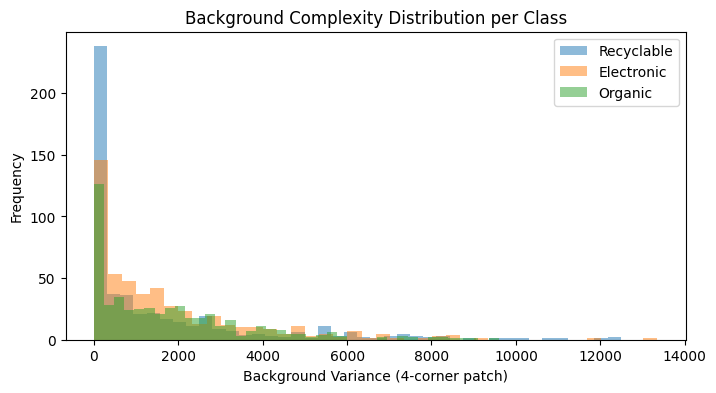

Proportion of plain-background images (variance < 50):
class
Electronic    15.4%
Organic       18.0%
Recyclable    36.0%
Name: is_plain_bg, dtype: object

Risk Flagged: Recyclable has a high rate of plain backgrounds.
Action: We will run Grad-CAM post-training to verify the model didn't learn this shortcut.


In [30]:
# Cell 12 - Shortcut Risk Analysis
# Analyzes background complexity to assess if the model might learn a background shortcut.
def compute_background_complexity(img_path, patch_size=30):
    try:
        img = Image.open(img_path).convert("RGB")
        arr = np.array(img)
        h, w, _ = arr.shape
        p = patch_size
        
        corners = [
            arr[0:p, 0:p],
            arr[0:p, w-p:w],
            arr[h-p:h, 0:p],
            arr[h-p:h, w-p:w]
        ]
        return np.mean([c.var() for c in corners])
    except Exception:
        return np.nan

random.seed(SEED)
bg_results = []
for label_id in [0, 1, 2]:
    subset = valid_train[valid_train["label"] == label_id]["filepath"].tolist()
    samples = random.sample(subset, min(500, len(subset)))
    for fp in samples:
        bg_results.append({
            "class": LABEL_MAP[label_id],
            "bg_variance": compute_background_complexity(fp)
        })

df_bg = pd.DataFrame(bg_results).dropna()

plt.figure(figsize=(8, 4))
for cls_name in ["Recyclable", "Electronic", "Organic"]:
    subset = df_bg[df_bg["class"] == cls_name]["bg_variance"]
    plt.hist(subset, bins=40, alpha=0.5, label=cls_name)

plt.xlabel("Background Variance (4-corner patch)")
plt.ylabel("Frequency")
plt.title("Background Complexity Distribution per Class")
plt.legend()
plt.show()

threshold = 50
df_bg["is_plain_bg"] = df_bg["bg_variance"] < threshold
print("Proportion of plain-background images (variance < 50):")
print(df_bg.groupby("class")["is_plain_bg"].mean().apply(lambda x: f"{x:.1%}"))
print("\nRisk Flagged: Recyclable has a high rate of plain backgrounds.")
print("Action: We will run Grad-CAM post-training to verify the model didn't learn this shortcut.")

In [31]:
# Cell 13 - Transforms and Dataset Classes (Supporting CLIP Norm & Soft KD)

# [PATCH 01] Menambahkan definisi fungsi yang hilang
def load_image_as_rgb(fp):
    return Image.open(fp).convert("RGB")

def get_transforms(img_size):
    """Standard ImageNet normalization for ConvNeXt & DINOv2."""
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    train_tfm = T.Compose([
        T.Resize((img_size, img_size), interpolation=InterpolationMode.BICUBIC),
        T.RandomHorizontalFlip(0.5),
        T.RandAugment(num_ops=2, magnitude=9),
        T.ColorJitter(brightness=0.2, contrast=0.1, saturation=0.1),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])
    eval_tfm = T.Compose([
        T.Resize((img_size, img_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])
    return train_tfm, eval_tfm

def get_transforms_clip(img_size):
    """CLIP-style normalization (mean=0.5, std=0.5) for EVA-02 & SigLIP-SO400M."""
    mean = [0.5, 0.5, 0.5]
    std  = [0.5, 0.5, 0.5]
    train_tfm = T.Compose([
        T.Resize((img_size, img_size), interpolation=InterpolationMode.BICUBIC),
        T.RandomHorizontalFlip(0.5),
        T.RandAugment(num_ops=2, magnitude=9),
        T.ColorJitter(brightness=0.2, contrast=0.1, saturation=0.1),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])
    eval_tfm = T.Compose([
        T.Resize((img_size, img_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])
    return train_tfm, eval_tfm

class WasteDataset(Dataset):
    def __init__(self, df, transform=None, img_size=384):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fp = row.get("filepath", None)
        if fp is None or not Path(fp).exists():
            folder = row.get("label_folder", CLASS_FOLDERS[int(row["label"])])
            fp = TRAIN_DIR / folder / row["filename"]
        img = load_image_as_rgb(fp)
        if self.transform:
            img = self.transform(img)
        label = int(row["label"])
        return img, label

class WasteDatasetWithPseudo(Dataset):
    """Combined Dataset: Real Train Samples + Soft Pseudo-Labeled Test Samples for KD."""
    def __init__(self, train_df, pseudo_df=None, transform=None, use_pseudo=True, pseudo_conf_thresh=0.95):
        self.transform = transform
        real = train_df[(~train_df["exclude_from_training"].astype(bool))].copy()
        real["is_pseudo"] = False
        real["soft_R"] = 0.0
        real["soft_E"] = 0.0
        real["soft_O"] = 0.0

        if use_pseudo and pseudo_df is not None and len(pseudo_df) > 0:
            pseudo = pseudo_df[pseudo_df["confidence"] >= pseudo_conf_thresh].copy()
            pseudo["is_pseudo"] = True
            pseudo["label"] = pseudo["hard_label"]
            self.df = pd.concat([real, pseudo], ignore_index=True)
            print(f"  Dataset: {len(real)} real + {len(pseudo)} pseudo = {len(self.df)} total")
        else:
            self.df = real.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fp = row.get("filepath", None)
        if fp is None or not Path(fp).exists():
            folder = row.get("label_folder", CLASS_FOLDERS[int(row["label"])])
            fp = TRAIN_DIR / folder / row["filename"]
        img = load_image_as_rgb(fp)
        if self.transform:
            img = self.transform(img)
        label = int(row["label"])
        is_pseudo = bool(row["is_pseudo"])
        soft = torch.tensor([row.get("soft_R", 0.0), row.get("soft_E", 0.0), row.get("soft_O", 0.0)], dtype=torch.float32)
        return img, label, soft, is_pseudo

In [32]:
# Cell 14 - Model Builder, Optimizer, Scheduler, and KD Loss

# [PATCH 08] Menambahkan parameter img_size dengan default None
def build_model(model_name, num_classes=3, pretrained=True, img_size=None):
    kwargs = {"pretrained": pretrained, "num_classes": num_classes}
    if img_size is not None:
        kwargs["img_size"] = img_size
    return timm.create_model(model_name, **kwargs)

def get_optimizer(model, backbone_lr, head_lr, weight_decay=WEIGHT_DECAY):
    backbone_params = []
    head_params = []
    for name, param in model.named_parameters():
        if not param.requires_grad: continue
        if "head" in name or "fc" in name or "classifier" in name:
            head_params.append(param)
        else:
            backbone_params.append(param)
    param_groups = [
        {"params": backbone_params, "lr": backbone_lr},
        {"params": head_params,     "lr": head_lr}
    ]
    return torch.optim.AdamW(param_groups, weight_decay=weight_decay)

def get_scheduler(optimizer, steps_per_epoch, num_epochs, warmup_ratio=WARMUP_STEPS_RATIO):
    total_steps  = steps_per_epoch * num_epochs
    warmup_steps = int(total_steps * warmup_ratio)
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))
        progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

class KDLoss(nn.Module):
    """Blends CrossEntropy with Temperature-scaled soft KL Divergence."""
    def __init__(self, T=KD_TEMPERATURE, alpha=KD_ALPHA, label_smoothing=LABEL_SMOOTHING):
        super().__init__()
        self.T = T
        self.alpha = alpha
        self.ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.kl = nn.KLDivLoss(reduction="batchmean")

    def forward(self, logits, hard_labels, soft_labels=None, is_pseudo=None):
        ce_loss = self.ce(logits, hard_labels)
        if soft_labels is None or is_pseudo is None or not is_pseudo.any():
            return ce_loss
        pseudo_mask = is_pseudo.bool()
        p_logits = logits[pseudo_mask] / self.T
        p_soft   = soft_labels[pseudo_mask] ** (1.0 / self.T)
        p_soft   = p_soft / p_soft.sum(dim=1, keepdim=True)
        kd_loss  = self.kl(F.log_softmax(p_logits, dim=1), p_soft) * (self.T ** 2)
        return self.alpha * ce_loss + (1.0 - self.alpha) * kd_loss

In [33]:
# Cell 15 - Training Utilities
# Core functions for training and validation.
# [PATCH] Dead code (old non-KD functions) removed for notebook cleanliness.

def update_ema(model, ema_model, decay=EMA_DECAY_CNN):
    with torch.no_grad():
        for ema_param, model_param in zip(ema_model.parameters(), model.parameters()):
            ema_param.data.mul_(decay).add_(model_param.data, alpha=1 - decay)

In [34]:
# Cell 16 - 5-Fold Training Runner (Supporting Pseudo-Label KD)
def train_one_epoch_kd(model, ema_model, loader, criterion, optimizer, scheduler, scaler, ema_decay):
    model.train()
    total_loss, total_norm = 0.0, 0.0
    for batch in tqdm(loader, leave=False, desc="Train"):
        if len(batch) == 4:
            imgs, labels, soft_labels, is_pseudo = batch
            soft_labels = soft_labels.to(DEVICE)
            is_pseudo   = is_pseudo.to(DEVICE)
        else:
            imgs, labels = batch
            soft_labels, is_pseudo = None, None

        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            logits = model(imgs)
            loss   = criterion(logits, labels, soft_labels, is_pseudo)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        with torch.no_grad():
            for p_ema, p_m in zip(ema_model.parameters(), model.parameters()):
                p_ema.data.mul_(ema_decay).add_(p_m.data, alpha=1.0 - ema_decay)

        total_loss += loss.item()
        total_norm += norm.item() if torch.isfinite(torch.tensor(norm)) else 0.0

    return {"loss": total_loss / len(loader), "grad_norm": total_norm / len(loader)}

@torch.no_grad()
def validate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_probs, all_preds, all_labels = [], [], []

    for imgs, labels in tqdm(loader, leave=False, desc="Val"):
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.amp.autocast("cuda"):
            logits = model(imgs)
            loss   = criterion(logits, labels)
            probs  = F.softmax(logits, dim=1)

        total_loss += loss.item() * imgs.size(0)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.argmax(probs, dim=1).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_probs  = np.concatenate(all_probs, axis=0)
    all_preds  = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    macro_f1   = f1_score(all_labels, all_preds, average="macro")
    per_class  = f1_score(all_labels, all_preds, average=None)

    return {
        "loss": total_loss / len(loader.dataset),
        "macro_f1": macro_f1,
        "f1_per_class": per_class,
        "probs": all_probs,
        "preds": all_preds,
        "labels": all_labels,
    }

def run_5fold_training(model_name, img_size, prefix, batch_size, backbone_lr, head_lr, ema_decay,
                       get_tfm_fn=get_transforms, pseudo_df=None, num_epochs=NUM_EPOCHS):
    print(f"\nSTARTING TRAINING: {prefix} ({model_name} @ {img_size}px, epochs={num_epochs})\n")
    train_tfm, eval_tfm = get_tfm_fn(img_size)
    criterion = KDLoss(T=KD_TEMPERATURE, alpha=KD_ALPHA, label_smoothing=LABEL_SMOOTHING)

    oof_probs  = np.zeros((len(train_master), 3), dtype=np.float32)
    oof_labels = np.full((len(train_master)), -1, dtype=int)
    fold_results = {}

    progress_file = OUTPUT_DIR / f"{prefix}_kfold_progress.json"
    completed_folds = []
    if progress_file.exists():
        with open(progress_file, "r") as f:
            completed_folds = json.load(f)
        print(f"Resuming {prefix}: Folds {completed_folds} completed.")

    for fold in range(N_SPLITS):
        if fold in completed_folds:
            ckpt_path = OUTPUT_DIR / f"{prefix}_fold{fold}_best.pt"
            ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
            oof_probs[ckpt["val_indices"]]  = ckpt["best_probs"]
            oof_labels[ckpt["val_indices"]] = ckpt["best_labels"]
            # [PATCH 10] Tambahkan key history saat resume
            fold_results[fold] = {
                "best_f1": ckpt["best_f1"], 
                "best_per_class_f1": ckpt.get("best_per_class_f1", None),
                "history": ckpt.get("history", {})
            }
            continue

        print(f"\n--- FOLD {fold+1}/{N_SPLITS} ---")
        train_df = train_master[(train_master["fold"] != fold) & (~train_master["exclude_from_training"].astype(bool))].copy()
        val_df   = train_master[(train_master["fold"] == fold) & (~train_master["exclude_from_training"].astype(bool))].copy()

        train_ds = WasteDatasetWithPseudo(train_df, pseudo_df, transform=train_tfm, use_pseudo=USE_PSEUDO_LABELING, pseudo_conf_thresh=PSEUDO_CONF_THRESH)
        val_ds   = WasteDataset(val_df, transform=eval_tfm, img_size=img_size)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
        val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

        model = build_model(model_name, pretrained=True).to(DEVICE)
        ema_model = copy.deepcopy(model).eval().to(DEVICE)
        optimizer = get_optimizer(model, backbone_lr, head_lr)
        scheduler = get_scheduler(optimizer, len(train_loader), num_epochs)
        scaler    = torch.amp.GradScaler("cuda")

        best_f1, best_probs, best_labels = 0.0, None, None
        best_per_class = None
        history = defaultdict(list)
        es_counter = 0

        for epoch in range(num_epochs):
            t_start = time.time()
            train_res = train_one_epoch_kd(model, ema_model, train_loader, criterion, optimizer, scheduler, scaler, ema_decay)
            val_res   = validate_epoch(ema_model, val_loader, nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING))
            elapsed   = time.time() - t_start

            history["train_loss"].append(train_res["loss"])
            history["val_loss"].append(val_res["loss"])
            history["val_macro_f1"].append(val_res["macro_f1"])

            per_class_str = " | ".join([f"{LABEL_MAP[i][:3]}: {val_res['f1_per_class'][i]:.3f}" for i in range(3)])
            print(f"Epoch {epoch+1:02d}/{num_epochs} | {elapsed:.0f}s | Train Loss: {train_res['loss']:.4f} | Val Loss: {val_res['loss']:.4f} | Val Macro F1: {val_res['macro_f1']:.4f}")
            print(f"  Per-class: {per_class_str}")

            if val_res["macro_f1"] > best_f1 + EARLY_STOPPING_MIN_DELTA:
                es_counter = 0
                best_f1        = val_res["macro_f1"]
                best_probs     = val_res["probs"]
                best_labels    = val_res["labels"]
                best_per_class = val_res["f1_per_class"]
                torch.save({
                    "epoch": epoch + 1,
                    "model_state_dict": ema_model.state_dict(),
                    "best_f1": best_f1,
                    "best_probs": best_probs,
                    "best_labels": best_labels,
                    "val_indices": val_df.index.to_numpy(),
                    "best_per_class_f1": best_per_class,
                    "run_id": RUN_ID,
                    "history": dict(history)
                }, OUTPUT_DIR / f"{prefix}_fold{fold}_best.pt")
                print(f"  -> Best saved! (F1: {best_f1:.4f})")
            else:
                es_counter += 1
                if es_counter >= EARLY_STOPPING_PATIENCE:
                    print(f"  Early stopping at epoch {epoch+1}")
                    break

        # [PATCH 10] Tambahkan key history saat training selesai
        fold_results[fold] = {
            "best_f1": best_f1, 
            "best_per_class_f1": best_per_class,
            "history": dict(history)
        }
        oof_probs[val_df.index]  = best_probs
        oof_labels[val_df.index] = best_labels

        completed_folds.append(fold)
        tmp_fd, tmp_path = tempfile.mkstemp(dir=OUTPUT_DIR)
        with os.fdopen(tmp_fd, "w") as f: json.dump(completed_folds, f)
        os.replace(tmp_path, progress_file)

        del model, ema_model, optimizer, scheduler, scaler
        torch.cuda.empty_cache()

    mean_cv = np.mean([fold_results[f]["best_f1"] for f in range(N_SPLITS)])
    print(f"\n{prefix.upper()} COMPLETE. 5-Fold Mean CV: {mean_cv:.4f}\n")
    return fold_results, oof_probs, oof_labels

In [ ]:
# Cell 17 - EXECUTION: ConvNeXt Training
# Train ConvNeXt V2 (384px)
convnext_fold_results, convnext_oof_probs, convnext_oof_labels = run_5fold_training(
    model_name=MODEL_NAME_CNN, 
    img_size=IMG_SIZE_CNN, 
    prefix="convnext", 
    batch_size=BATCH_SIZE_CNN, 
    backbone_lr=BACKBONE_LR_CNN, 
    head_lr=HEAD_LR, 
    ema_decay=EMA_DECAY_CNN
)


STARTING TRAINING: convnext (convnextv2_tiny.fcmae_ft_in22k_in1k_384 @ 512px, epochs=40)


--- FOLD 1/5 ---


2026-07-29 19:30:52,050 [INFO] Loading pretrained weights from Hugging Face hub (timm/convnextv2_tiny.fcmae_ft_in22k_in1k_384)
2026-07-29 19:30:52,152 [INFO] HTTP Request: HEAD https://huggingface.co/timm/convnextv2_tiny.fcmae_ft_in22k_in1k_384/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-07-29 19:30:52,153 [WARNING] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-07-29 19:30:52,209 [INFO] HTTP Request: GET https://huggingface.co/api/models/timm/convnextv2_tiny.fcmae_ft_in22k_in1k_384/xet-read-token/388f5731d1f9bb4442aee26bcb356983a95589dd "HTTP/1.1 200 OK"


model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

2026-07-29 19:30:55,565 [INFO] [timm/convnextv2_tiny.fcmae_ft_in22k_in1k_384] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
2026-07-29 19:30:55,603 [INFO] Missing keys (head.fc.weight, head.fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.


Train:   0%|          | 0/883 [00:00<?, ?it/s]